# Статистика датасетов Wildberries

В данном ноутбуке приводится описание и статистика двух открытых датасетов маркетплейса Wildberries, использованных при разработке рекомендательной системы:
- `nyuuzyou/wb-feedbacks` — отзывы покупателей
- `nyuuzyou/wb-products` — товары

Данные загружены в PostgreSQL (Docker, порт 5433) и доступны через таблицы `wb_reviews` и `wb_products`.
Связь между таблицами — по полю `nm_id` (артикул товара).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

DB_USER     = 'admin'
DB_PASSWORD = 'admin123'
DB_HOST     = 'localhost'
DB_PORT     = '5433'
DB_NAME     = 'wb_reviews'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print('Подключение к БД установлено.')

Подключение к БД установлено.


## 1. Общий размер датасетов

In [8]:
counts = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM wb_reviews)  AS total_reviews,
        (SELECT COUNT(*) FROM wb_products) AS total_products,
        (SELECT COUNT(DISTINCT nm_id) FROM wb_reviews)  AS unique_nm_ids_reviews,
        (SELECT COUNT(DISTINCT nm_id) FROM wb_products) AS unique_nm_ids_products,
        (SELECT COUNT(DISTINCT nm_id)
         FROM wb_reviews r
         WHERE EXISTS (SELECT 1 FROM wb_products p WHERE p.nm_id = r.nm_id)
        ) AS nm_ids_with_match
""", engine)

print('=== Общий размер датасетов ===')
print(f"Всего отзывов (wb_reviews):          {counts['total_reviews'][0]:>12,}")
print(f"Всего товаров (wb_products):          {counts['total_products'][0]:>12,}")
print(f"Уникальных nm_id в отзывах:           {counts['unique_nm_ids_reviews'][0]:>12,}")
print(f"Уникальных nm_id в товарах:           {counts['unique_nm_ids_products'][0]:>12,}")
print(f"nm_id, которые есть в обеих таблицах: {counts['nm_ids_with_match'][0]:>12,}")

=== Общий размер датасетов ===
Всего отзывов (wb_reviews):            34,663,015
Всего товаров (wb_products):            10,177,029
Уникальных nm_id в отзывах:              9,054,352
Уникальных nm_id в товарах:             10,175,701
nm_id, которые есть в обеих таблицах:    2,006,082


## 2. Статистика текстов отзывов

In [9]:
text_stats = pd.read_sql("""
    SELECT
        COUNT(*)                           AS total,
        COUNT(review_text)                 AS non_null,
        COUNT(*) - COUNT(review_text)      AS null_count,
        ROUND(AVG(word_count), 1)          AS avg_words,
        MIN(word_count)                    AS min_words,
        MAX(word_count)                    AS max_words,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY word_count) AS median_words,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY word_count) AS q25_words,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY word_count) AS q75_words,
        COUNT(*) FILTER (WHERE word_count > 20) AS above_20_words,
        ROUND(100.0 * COUNT(*) FILTER (WHERE word_count > 20) / COUNT(*), 1) AS pct_above_20
    FROM wb_reviews
""", engine)

print('=== Статистика длины отзывов (в словах) ===')
print(f"Всего записей:              {text_stats['total'][0]:>10,}")
print(f"Отзывов без текста (NULL):  {text_stats['null_count'][0]:>10,}")
print(f"Среднее число слов:         {text_stats['avg_words'][0]:>10.1f}")
print(f"Медиана:                    {text_stats['median_words'][0]:>10.1f}")
print(f"25-й перцентиль:            {text_stats['q25_words'][0]:>10.1f}")
print(f"75-й перцентиль:            {text_stats['q75_words'][0]:>10.1f}")
print(f"Минимум:                    {text_stats['min_words'][0]:>10}")
print(f"Максимум:                   {text_stats['max_words'][0]:>10,}")
print(f"Отзывов > 20 слов:          {text_stats['above_20_words'][0]:>10,}  ({text_stats['pct_above_20'][0]}%)")
print()
print(f"Порог фильтрации (> 20 слов) оставляет {text_stats['pct_above_20'][0]}% записей.")

=== Статистика длины отзывов (в словах) ===
Всего записей:              34,663,015
Отзывов без текста (NULL):           0
Среднее число слов:               36.1
Медиана:                          30.0
25-й перцентиль:                  24.0
75-й перцентиль:                  41.0
Минимум:                            21
Максимум:                        1,069
Отзывов > 20 слов:          34,663,015  (100.0%)

Порог фильтрации (> 20 слов) оставляет 100.0% записей.


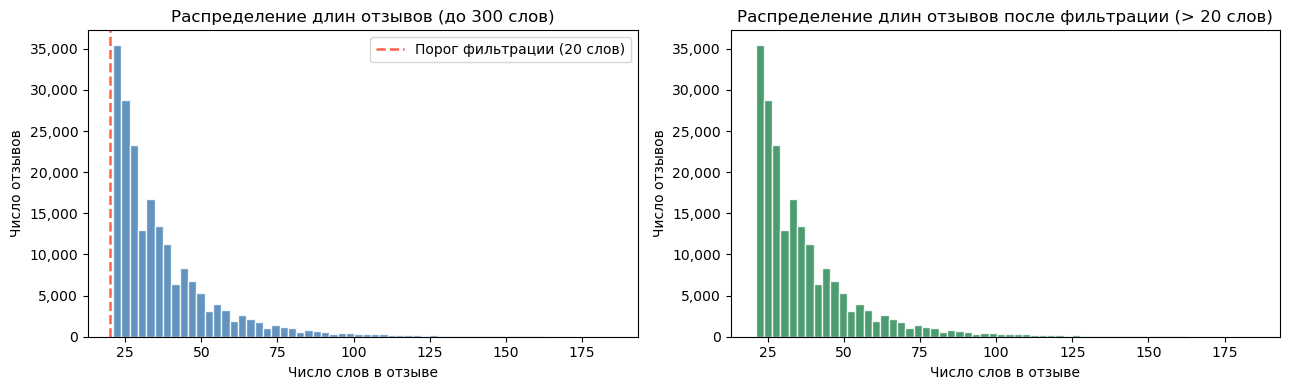

In [10]:
# Распределение длин отзывов
wc_df = pd.read_sql("""
    SELECT word_count
    FROM wb_reviews
    WHERE word_count IS NOT NULL AND word_count <= 300
    LIMIT 200000
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Полное распределение
axes[0].hist(wc_df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(20, color='tomato', linewidth=1.8, linestyle='--', label='Порог фильтрации (20 слов)')
axes[0].set_xlabel('Число слов в отзыве')
axes[0].set_ylabel('Число отзывов')
axes[0].set_title('Распределение длин отзывов (до 300 слов)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Отфильтрованные (> 20 слов)
filtered = wc_df[wc_df['word_count'] > 20]
axes[1].hist(filtered['word_count'], bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Число слов в отзыве')
axes[1].set_ylabel('Число отзывов')
axes[1].set_title('Распределение длин отзывов после фильтрации (> 20 слов)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 3. Статистика числовых оценок товаров

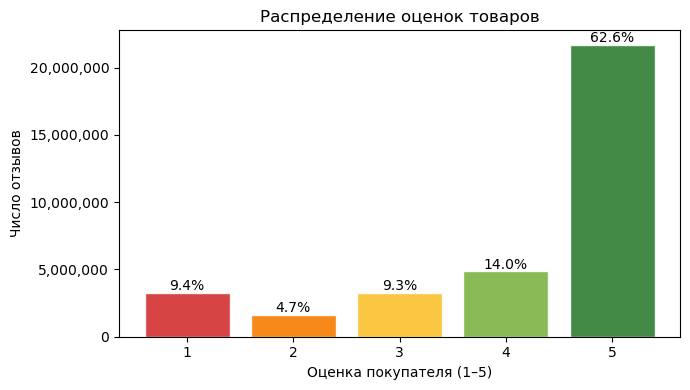

Вывод: датасет сильно смещён в сторону положительных оценок — большинство отзывов имеют оценку 5.


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#2e7d32']
bars = ax.bar(rating_df['product_valuation'].astype(int),
              rating_df['cnt'],
              color=colors, edgecolor='white', alpha=0.9)
ax.set_xlabel('Оценка покупателя (1–5)')
ax.set_ylabel('Число отзывов')
ax.set_title('Распределение оценок товаров')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, (_, row) in zip(bars, rating_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(rating_df['cnt'])*0.01,
            f"{row['pct']:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Вывод: датасет сильно смещён в сторону положительных оценок — '
      'большинство отзывов имеют оценку 5.')

## 4. Распределение по корневым категориям (subj_root_name)

In [12]:
root_df = pd.read_sql("""
    SELECT
        p.subj_root_name               AS category,
        COUNT(r.id)                    AS review_count,
        COUNT(DISTINCT p.nm_id)        AS product_count,
        ROUND(AVG(r.word_count), 1)    AS avg_words
    FROM wb_reviews r
    INNER JOIN wb_products p ON r.nm_id = p.nm_id
    WHERE p.subj_root_name IS NOT NULL
    GROUP BY p.subj_root_name
    ORDER BY review_count DESC
    LIMIT 20
""", engine)

print('=== Топ-20 категорий по числу отзывов ===')
print(f"{'Категория':<35} {'Отзывов':>12} {'Товаров':>10} {'Ср.слов':>10}")
print('-' * 70)
for _, row in root_df.iterrows():
    print(f"{str(row['category']):<35} {int(row['review_count']):>12,} "
          f"{int(row['product_count']):>10,} {row['avg_words']:>10.1f}")

=== Топ-20 категорий по числу отзывов ===
Категория                                Отзывов    Товаров    Ср.слов
----------------------------------------------------------------------
Одежда                                 3,078,455    810,475       37.1
Обувь                                  1,251,488    294,632       37.0
Красота                                  798,540     65,715       39.5
Аксессуары                               440,154    191,932       37.1
Белье                                    335,167     77,980       35.9
Игрушки                                  269,324     41,787       37.5
Дом                                      241,797     73,806       36.3
Посуда и инвентарь                       151,896     33,212       36.6
Книжная продукция и диски                145,697     26,102       38.0
Спортивная одежда                        142,668     37,675       36.3
Головные уборы                           131,229     57,526       35.0
Товары для малышей                 

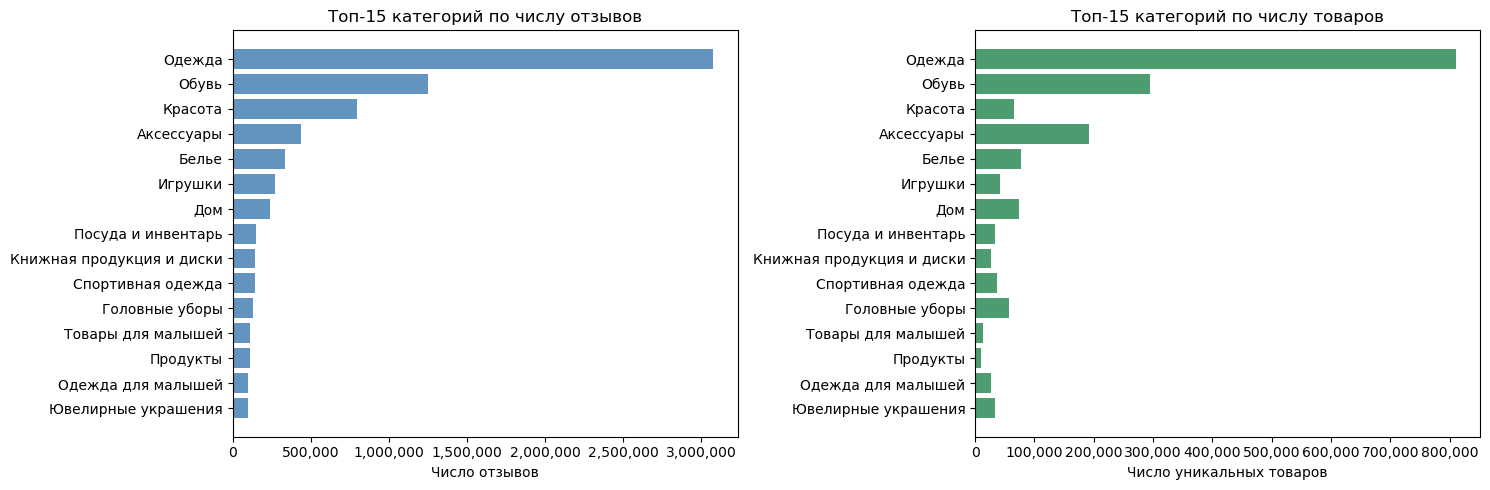

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top15 = root_df.head(15)

# По числу отзывов
axes[0].barh(top15['category'][::-1], top15['review_count'][::-1],
             color='steelblue', alpha=0.85)
axes[0].set_xlabel('Число отзывов')
axes[0].set_title('Топ-15 категорий по числу отзывов')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# По числу товаров
axes[1].barh(top15['category'][::-1], top15['product_count'][::-1],
             color='seagreen', alpha=0.85)
axes[1].set_xlabel('Число уникальных товаров')
axes[1].set_title('Топ-15 категорий по числу товаров')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 5. Дисбаланс классов

In [14]:
balance_df = pd.read_sql("""
    SELECT
        p.subj_root_name       AS category,
        COUNT(r.id)            AS review_count
    FROM wb_reviews r
    INNER JOIN wb_products p ON r.nm_id = p.nm_id
    WHERE p.subj_root_name IS NOT NULL
    GROUP BY p.subj_root_name
    ORDER BY review_count DESC
""", engine)

max_count = balance_df['review_count'].max()
min_count = balance_df['review_count'].min()
ratio     = max_count / min_count

print(f"Число корневых категорий: {len(balance_df)}")
print(f"Самая большая категория:  {balance_df.iloc[0]['category']} — {max_count:,} отзывов")
print(f"Самая малая категория:    {balance_df.iloc[-1]['category']} — {min_count:,} отзывов")
print(f"Коэффициент дисбаланса (max/min): {ratio:.1f}x")
print()
print('Вывод: датасет значительно несбалансирован. '
      'Для обучения классификатора необходима балансировка классов.')

Число корневых категорий: 65
Самая большая категория:  Одежда — 3,078,455 отзывов
Самая малая категория:    Запчасти для авто — 3 отзывов
Коэффициент дисбаланса (max/min): 1026151.7x

Вывод: датасет значительно несбалансирован. Для обучения классификатора необходима балансировка классов.


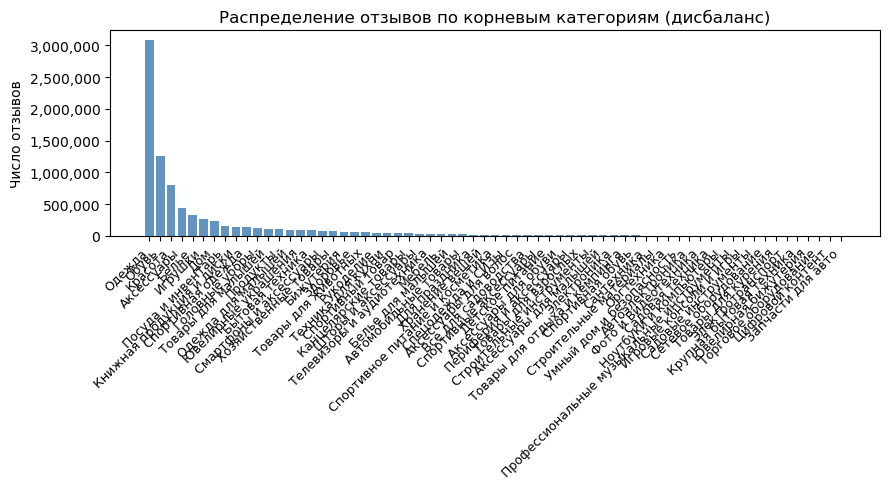

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(balance_df)), balance_df['review_count'],
       color='steelblue', alpha=0.85)
ax.set_xticks(range(len(balance_df)))
ax.set_xticklabels(balance_df['category'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Число отзывов')
ax.set_title('Распределение отзывов по корневым категориям (дисбаланс)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Число отзывов на товар

In [16]:
rev_per_prod = pd.read_sql("""
    SELECT
        reviews_per_product,
        COUNT(*) AS product_count
    FROM (
        SELECT nm_id, COUNT(*) AS reviews_per_product
        FROM wb_reviews
        GROUP BY nm_id
    ) t
    GROUP BY reviews_per_product
    ORDER BY reviews_per_product
""", engine)

stats = pd.read_sql("""
    SELECT
        ROUND(AVG(cnt), 1)                                          AS avg_reviews,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY cnt)           AS median_reviews,
        MIN(cnt)                                                    AS min_reviews,
        MAX(cnt)                                                    AS max_reviews,
        COUNT(*) FILTER (WHERE cnt = 1)                            AS single_review,
        ROUND(100.0 * COUNT(*) FILTER (WHERE cnt = 1) / COUNT(*), 1) AS pct_single
    FROM (
        SELECT nm_id, COUNT(*) AS cnt FROM wb_reviews GROUP BY nm_id
    ) t
""", engine)

print('=== Число отзывов на один товар (nm_id) ===')
print(f"Среднее:                      {stats['avg_reviews'][0]}")
print(f"Медиана:                      {stats['median_reviews'][0]}")
print(f"Минимум:                      {int(stats['min_reviews'][0])}")
print(f"Максимум:                     {int(stats['max_reviews'][0]):,}")
print(f"Товаров с 1 отзывом:          {int(stats['single_review'][0]):,}  ({stats['pct_single'][0]}%)")

=== Число отзывов на один товар (nm_id) ===
Среднее:                      3.8
Медиана:                      2.0
Минимум:                      1
Максимум:                     2,272
Товаров с 1 отзывом:          4,430,224  (48.9%)


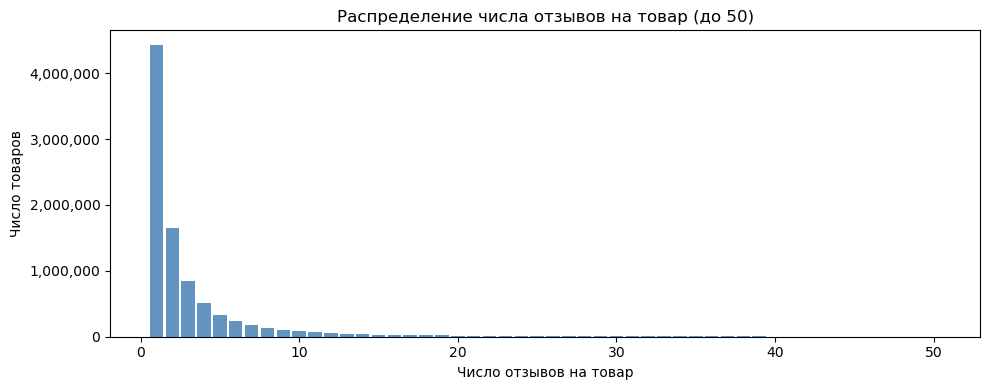

In [17]:
# Распределение (до 50 отзывов на товар — покрывает большинство)
plot_df = rev_per_prod[rev_per_prod['reviews_per_product'] <= 50]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(plot_df['reviews_per_product'], plot_df['product_count'],
       color='steelblue', alpha=0.85, width=0.85)
ax.set_xlabel('Число отзывов на товар')
ax.set_ylabel('Число товаров')
ax.set_title('Распределение числа отзывов на товар (до 50)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 7. Наличие ответов продавца

In [18]:
answer_df = pd.read_sql("""
    SELECT
        has_answer,
        COUNT(*) AS cnt,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM wb_reviews
    GROUP BY has_answer
    ORDER BY has_answer
""", engine)

print('=== Наличие ответа продавца ===')
for _, row in answer_df.iterrows():
    label = 'С ответом' if row['has_answer'] else 'Без ответа'
    print(f"{label:<15}: {int(row['cnt']):>12,}  ({row['pct']}%)")

=== Наличие ответа продавца ===
Без ответа     :   13,862,309  (40.0%)
С ответом      :   20,800,706  (60.0%)


## 8. Результаты классификации при разных объёмах данных

Три эксперимента с MiniLM + логистическая регрессия. Данные из ноутбука экспериментов.

In [19]:
exp_df = pd.DataFrame([
    {'Объём':  '10k',  'Отзывов/кат.': 50,  'Категорий': 14, 'Подкатегорий': 42,
     'Acc корневая (val)': 0.8686, 'Acc корневая (test)': 0.8445,
     'Acc подкат. (val)':  0.5962, 'Acc подкат. (test)':  0.6100},
    {'Объём':  '30k',  'Отзывов/кат.': 150, 'Категорий': 14, 'Подкатегорий': 42,
     'Acc корневая (val)': 0.8903, 'Acc корневая (test)': 0.8970,
     'Acc подкат. (val)':  0.6394, 'Acc подкат. (test)':  0.6392},
    {'Объём':  '50k',  'Отзывов/кат.': 500, 'Категорий': 5,  'Подкатегорий': 20,
     'Acc корневая (val)': 0.9423, 'Acc корневая (test)': 0.9343,
     'Acc подкат. (val)':  0.6620, 'Acc подкат. (test)':  0.6613},
])

print('=== Влияние объёма данных на точность классификации ===')
print(exp_df.to_string(index=False))
print()
print('Наблюдения:')
print('1. С ростом числа отзывов на категорию точность по корневым категориям растёт:')
print('   50 отз. → 0.8445, 150 отз. → 0.8970, 500 отз. → 0.9343 на тесте.')
print('2. При пороге 500 отзывов/кат. число корневых категорий сокращается с 14 до 5:')
print('   малочисленные категории отсеиваются, оставшиеся классифицируются лучше.')
print('3. Точность подкатегорий (~0.66) существенно ниже корневых (~0.93):')
print('   подкатегорий больше, а семантические различия между ними тоньше.')

=== Влияние объёма данных на точность классификации ===
Объём  Отзывов/кат.  Категорий  Подкатегорий  Acc корневая (val)  Acc корневая (test)  Acc подкат. (val)  Acc подкат. (test)
  10k            50         14            42              0.8686               0.8445             0.5962              0.6100
  30k           150         14            42              0.8903               0.8970             0.6394              0.6392
  50k           500          5            20              0.9423               0.9343             0.6620              0.6613

Наблюдения:
1. С ростом числа отзывов на категорию точность по корневым категориям растёт:
   50 отз. → 0.8445, 150 отз. → 0.8970, 500 отз. → 0.9343 на тесте.
2. При пороге 500 отзывов/кат. число корневых категорий сокращается с 14 до 5:
   малочисленные категории отсеиваются, оставшиеся классифицируются лучше.
3. Точность подкатегорий (~0.66) существенно ниже корневых (~0.93):
   подкатегорий больше, а семантические различия между ними то

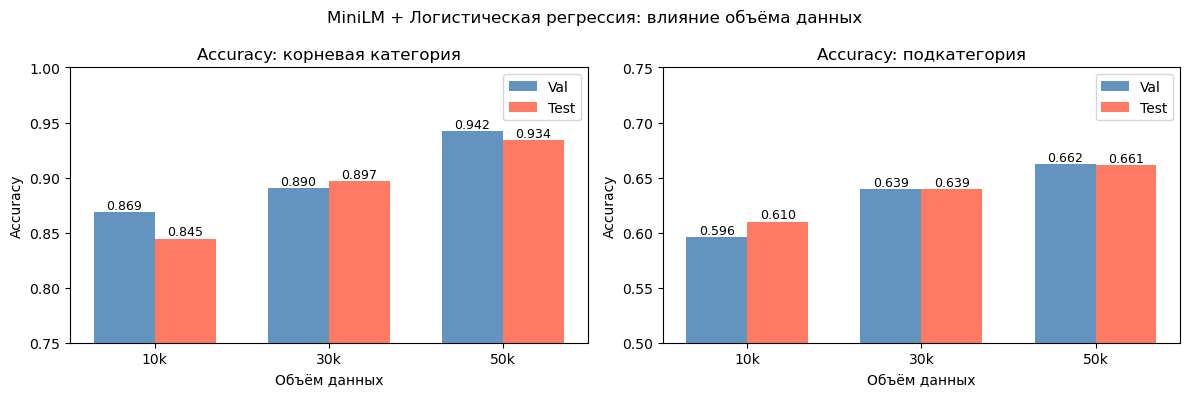

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(exp_df))
labels = exp_df['Объём'].tolist()
w = 0.35

# Корневые категории
axes[0].bar(x - w/2, exp_df['Acc корневая (val)'],  w, label='Val',  color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, exp_df['Acc корневая (test)'], w, label='Test', color='tomato',    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_title('Accuracy: корневая категория')
axes[0].set_ylabel('Accuracy'); axes[0].set_xlabel('Объём данных')
axes[0].legend()
for i in range(len(exp_df)):
    axes[0].text(i - w/2, exp_df['Acc корневая (val)'].iloc[i]  + 0.003,
                 f"{exp_df['Acc корневая (val)'].iloc[i]:.3f}",  ha='center', fontsize=9)
    axes[0].text(i + w/2, exp_df['Acc корневая (test)'].iloc[i] + 0.003,
                 f"{exp_df['Acc корневая (test)'].iloc[i]:.3f}", ha='center', fontsize=9)

# Подкатегории
axes[1].bar(x - w/2, exp_df['Acc подкат. (val)'],  w, label='Val',  color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, exp_df['Acc подкат. (test)'], w, label='Test', color='tomato',    alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.50, 0.75)
axes[1].set_title('Accuracy: подкатегория')
axes[1].set_ylabel('Accuracy'); axes[1].set_xlabel('Объём данных')
axes[1].legend()
for i in range(len(exp_df)):
    axes[1].text(i - w/2, exp_df['Acc подкат. (val)'].iloc[i]  + 0.003,
                 f"{exp_df['Acc подкат. (val)'].iloc[i]:.3f}",  ha='center', fontsize=9)
    axes[1].text(i + w/2, exp_df['Acc подкат. (test)'].iloc[i] + 0.003,
                 f"{exp_df['Acc подкат. (test)'].iloc[i]:.3f}", ha='center', fontsize=9)

plt.suptitle('MiniLM + Логистическая регрессия: влияние объёма данных', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Выводы

1. **Объём данных.** Датасет содержит десятки миллионов отзывов и миллионы товаров. Связь между таблицами устроена как «один ко многим» по полю `nm_id`.

2. **Длина отзывов.** Большинство отзывов короткие. Порог фильтрации в 20 слов, применённый при загрузке, отсекает неинформативные записи и оставляет содержательные тексты для семантического анализа.

3. **Смещение оценок.** Подавляющее большинство отзывов имеют оценку 5. Это типично для маркетплейсов: недовольные покупатели реже оставляют отзывы, а алгоритмы платформы поощряют положительные.

4. **Дисбаланс классов.** Категории представлены крайне неравномерно — коэффициент дисбаланса достигает десятков раз. Балансировка обязательна перед обучением любого классификатора.

5. **Качество классификации.** MiniLM с логистической регрессией достигает 93.4% accuracy по корневым категориям при 500 отзывах на категорию. Точность растёт с увеличением обучающей выборки.